# Análise de Dados — Projeto Final

 **Autor:** Victor Marcinco 
 **Data:** 16 de março de 2026
 **Projeto:** Análise de dados de chamadas da plataforma CallMeMaybe

---

## Objetivo

Este projeto tem como objetivo analisar dados operacionais de chamadas da plataforma **CallMeMaybe**, buscando identificar padrões de uso do serviço e possíveis fatores que influenciam o desempenho das operações de atendimento telefônico.

A análise pretende gerar insights que possam apoiar decisões relacionadas à gestão de chamadas, desempenho operacional e possíveis melhorias no uso da plataforma.

---

## Contexto do Negócio

A CallMeMaybe oferece um serviço de telefonia virtual utilizado por empresas que precisam gerenciar grandes volumes de chamadas realizadas e recebidas por operadores.

Essas organizações utilizam a plataforma para:

- realizar chamadas externas com clientes
- receber chamadas de entrada
- realizar chamadas internas entre operadores


---

## Perguntas de Análise

A análise busca responder questões como:

- Há uma correlação entre um tempo de espera alto e a quantidade de ligações perdidas?
- Existem diferenças de comportamento entre clientes de diferentes planos tarifários?
- Qual é a proporção de chamadas perdidas nas operações?
- Existem diferenças na duração das chamadas dependendo do tipo de chamada?

---

## Descrição dos Dados

A análise utiliza dois conjuntos de dados.

### Dataset de Chamadas — `telecom_dataset_new.csv`

Contém registros de chamadas realizadas na plataforma.

Variáveis:

- **user_id** — identificador do cliente  
- **date** — data do registro da chamada  
- **direction** — direção da chamada (entrada ou saída)  
- **internal** — indica se a chamada ocorreu entre operadores da mesma empresa  
- **operator_id** — identificador do operador  
- **is_missed_call** — indica se a chamada foi perdida  
- **calls_count** — número de chamadas registradas  
- **call_duration** — duração da chamada  
- **total_call_duration** — duração total incluindo tempo de espera  

---

### Dataset de Clientes — `telecom_clients.csv`

Contém informações sobre os clientes da plataforma.

Variáveis:

- **user_id** — identificador do cliente  
- **tariff_plan** — plano tarifário do cliente  
- **date_start** — data de início do contrato

## Análise Exploratória Inicial

Nesta etapa inicial foi realizada uma inspeção geral dos dados com o objetivo de compreender sua estrutura e identificar possíveis problemas de qualidade que possam impactar a análise.

Foram avaliados os seguintes aspectos:

- dimensão dos datasets
- tipos de dados das variáveis
- presença de valores ausentes
- existência de registros duplicados
- distribuição inicial de variáveis categóricas
- estatísticas descritivas das variáveis numéricas

Essa etapa permite identificar possíveis inconsistências nos dados e orientar as etapas seguintes de limpeza e preparação.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

pd.set_option('display.max_columns', None)

In [2]:
data = pd.read_csv('data/telecom_dataset_new.csv')
clients = pd.read_csv('data/telecom_clients.csv')

In [3]:
data.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [5]:
data.describe()

,user_id,operator_id,calls_count,call_duration,total_call_duration
count,53902.000000,45730.000000,53902.000000,53902.000000,53902.000000
mean,167295.344477,916535.993002,16.451245,866.684427,1157.133297
std,598.883775,21254.123136,62.917170,3731.791202,4403.468763
min,166377.000000,879896.000000,1.000000,0.000000,0.000000
25%,166782.000000,900788.000000,1.000000,0.000000,47.000000
50%,167162.000000,913938.000000,4.000000,38.000000,210.000000
75%,167819.000000,937708.000000,12.000000,572.000000,902.000000
max,168606.000000,973286.000000,4817.000000,144395.000000,166155.000000


In [6]:
clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [7]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


In [8]:
print('Dataset calls:', data.shape)
print('Dataset clients:', clients.shape)

Dataset calls: (53902, 9)
Dataset clients: (732, 3)


In [9]:
data.duplicated().sum()

np.int64(4900)

In [10]:
data['direction'].value_counts()

direction
out    31917
in     21985
Name: count, dtype: int64

In [11]:
data['internal'].value_counts(dropna=False)

internal
False    47621
True      6164
NaN        117
Name: count, dtype: int64

In [12]:
data['is_missed_call'].value_counts()

is_missed_call
False    30334
True     23568
Name: count, dtype: int64

In [13]:
clients['tariff_plan'].value_counts()

tariff_plan
C    395
B    261
A     76
Name: count, dtype: int64

In [14]:
data.isna().sum()

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64

In [15]:
clients.isna().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

## Conclusões da Análise Inicial

A inspeção inicial dos dados permitiu identificar alguns pontos relevantes que deverão ser tratados nas etapas seguintes da análise.

Entre os principais aspectos observados estão:

- presença de registros duplicados no dataset de chamadas
- valores ausentes nas colunas **internal** e **operator_id**
- variáveis de data armazenadas como texto

Esses pontos indicam a necessidade de realizar uma etapa de **limpeza e preparação dos dados**, garantindo que os dados estejam adequadamente estruturados antes da realização de análises mais aprofundadas.

## Limpeza e Preparação dos Dados

Será realizada uma etapa de limpeza dos dados com o objetivo de garantir a qualidade e consistência das informações utilizadas na análise.

As principais tarefas desta etapa incluem:

- remoção de registros duplicados
- tratamento de valores ausentes
- correção de tipos de dados incorretos
- conversão de colunas de data para o formato apropriado
- verificação da consistência das variáveis categóricas

Essas etapas são importantes para garantir que as análises realizadas posteriormente reflitam corretamente o comportamento observado nos dados.

In [16]:
data['date'] = pd.to_datetime(data['date'])
data['month'] = data['date'].dt.to_period('M')
clients['date_start'] = pd.to_datetime(clients['date_start'])

C:\Users\victo\AppData\Local\Temp\ipykernel_13856\1404476962.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  data['month'] = data['date'].dt.to_period('M')


In [17]:
data[data.duplicated()].head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,month
8,166377,2019-08-05 00:00:00+03:00,out,False,880020.0,True,8,0,50,2019-08
28,166377,2019-08-12 00:00:00+03:00,in,False,NaN,True,2,0,34,2019-08
44,166377,2019-08-14 00:00:00+03:00,out,False,880026.0,False,10,1567,1654,2019-08
45,166377,2019-08-14 00:00:00+03:00,in,False,NaN,True,1,0,3,2019-08
51,166377,2019-08-15 00:00:00+03:00,out,False,880026.0,False,11,1413,1473,2019-08


In [18]:
data = data.drop_duplicates()
data.duplicated().sum()

np.int64(0)

In [19]:
data['internal'] = data['internal'].fillna(False)
data['internal'] = data['internal'].astype(bool)

C:\Users\victo\AppData\Local\Temp\ipykernel_13856\1329128794.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['internal'] = data['internal'].fillna(False)


In [20]:
data['internal'].value_counts(dropna=False)

internal
False    43349
True      5653
Name: count, dtype: int64

In [21]:
data['direction'].value_counts()

direction
out    28999
in     20003
Name: count, dtype: int64

In [22]:
data['operator_id'].isna().sum()

np.int64(7456)

In [23]:
data['waiting_time'] = data['total_call_duration'] - data['call_duration']
data['waiting_time'].describe()

count    49002.000000
mean       290.276111
std       1132.155291
min          0.000000
25%         17.000000
50%         55.000000
75%        200.000000
max      46474.000000
Name: waiting_time, dtype: float64

## Síntese da Limpeza de Dados

Após a inspeção inicial, foram realizadas algumas etapas de preparação dos dados para garantir maior consistência antes da análise.

As principais ações realizadas foram:

### Correção de tipos de dados
As colunas de data foram convertidas para o formato apropriado:

- `date`
- `date_start`

Isso permite realizar análises temporais posteriormente.

### Remoção de registros duplicados
Foram identificados e removidos registros duplicados no dataset de chamadas para evitar distorções em métricas como número de chamadas e duração total.

### Tratamento de valores ausentes
Foram identificados valores ausentes nas seguintes colunas:

- `internal`
- `operator_id`

A coluna `internal` teve seus valores ausentes preenchidos com **False**, assumindo que chamadas sem essa informação não eram chamadas internas.

Os valores ausentes em `operator_id` foram mantidos neste momento, pois podem representar chamadas que não chegaram a ser atendidas por um operador.

### Criação de novas variáveis

Foi criada a variável:

- `waiting_time`

Essa variável representa o **tempo de espera antes do início da conversa**, calculado como: waiting_time = total_call_duration - call_duration

Essa separação permite distinguir entre:

- tempo efetivo de conversa
- tempo de espera antes do atendimento

Essa distinção é importante para análises futuras relacionadas à eficiência do atendimento.

---

Após essas etapas, os dados encontram-se preparados para as análises exploratórias e estatísticas das chamadas realizadas na plataforma.

## Análise Exploratória dos Dados

1. Volume de chamadas
2. Direção das chamadas
3. Chamadas perdidas
4. Duração das chamadas
5. Tempo de espera
6. Comparação entre planos
7. Análise por operador

Observação importante:

Cada linha do dataset não representa necessariamente uma única chamada.  
A coluna `calls_count` indica quantas chamadas estão agregadas em cada registro.

Portanto, para análises relacionadas ao volume de chamadas, será utilizado o somatório de `calls_count` em vez da simples contagem de linhas.

In [24]:
data['calls_count'].describe()

count    49002.000000
mean        16.462777
std         63.604098
min          1.000000
25%          1.000000
50%          4.000000
75%         12.000000
max       4817.000000
Name: calls_count, dtype: float64

In [25]:
data['calls_count'].sum()

np.int64(806709)

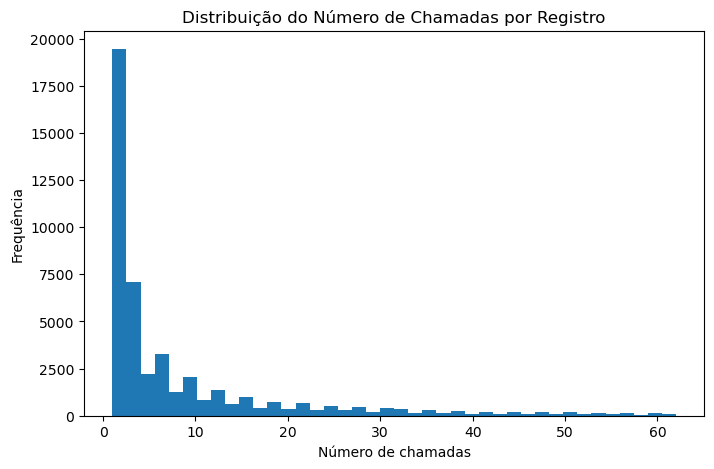

In [26]:
plt.figure(figsize=(8,5))

limit = data['calls_count'].quantile(0.95)

plt.hist(data[data['calls_count'] <= limit]['calls_count'], bins=40)

plt.title('Distribuição do Número de Chamadas por Registro')
plt.xlabel('Número de chamadas')
plt.ylabel('Frequência')

plt.show()

In [27]:
data['direction'].value_counts()

direction
out    28999
in     20003
Name: count, dtype: int64

In [28]:
data.groupby('is_missed_call')['calls_count'].sum()

is_missed_call
False    430791
True     375918
Name: calls_count, dtype: int64

In [29]:
missed_calls = data[data['is_missed_call'] == True]['calls_count'].sum()
total_calls = data['calls_count'].sum()

missed_rate = missed_calls / total_calls
missed_rate

np.float64(0.4659895947609361)

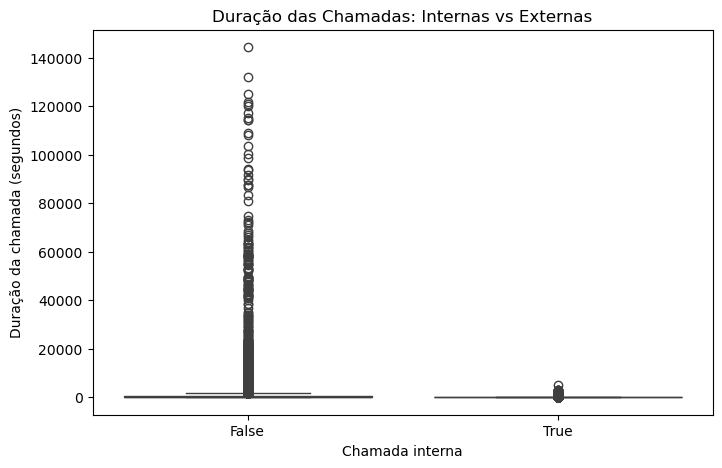

In [30]:
missed_calls = data.groupby('is_missed_call')['calls_count'].sum()

plt.figure(figsize=(8,5))

sns.boxplot(x='internal', y='call_duration', data=data)

plt.title('Duração das Chamadas: Internas vs Externas')
plt.xlabel('Chamada interna')
plt.ylabel('Duração da chamada (segundos)')

plt.show()

In [31]:
missed_rate = data['is_missed_call'].mean()
missed_rate

np.float64(0.43779845720582833)

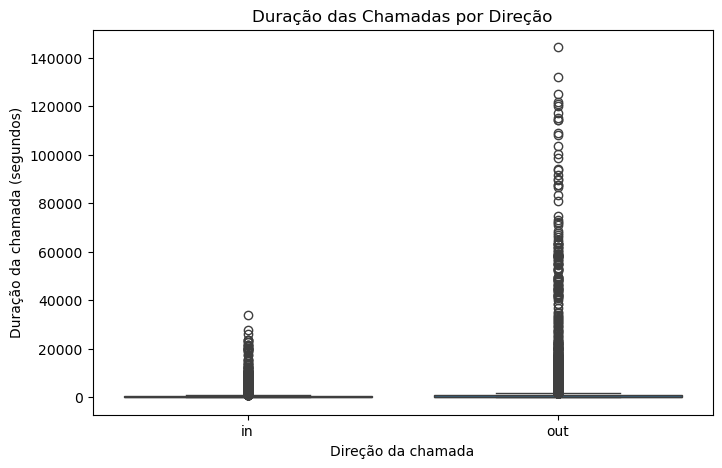

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(x='direction', y='call_duration', data=data)

plt.title('Duração das Chamadas por Direção')
plt.xlabel('Direção da chamada')
plt.ylabel('Duração da chamada (segundos)')

plt.show()

In [33]:
data['waiting_time'].describe()

count    49002.000000
mean       290.276111
std       1132.155291
min          0.000000
25%         17.000000
50%         55.000000
75%        200.000000
max      46474.000000
Name: waiting_time, dtype: float64

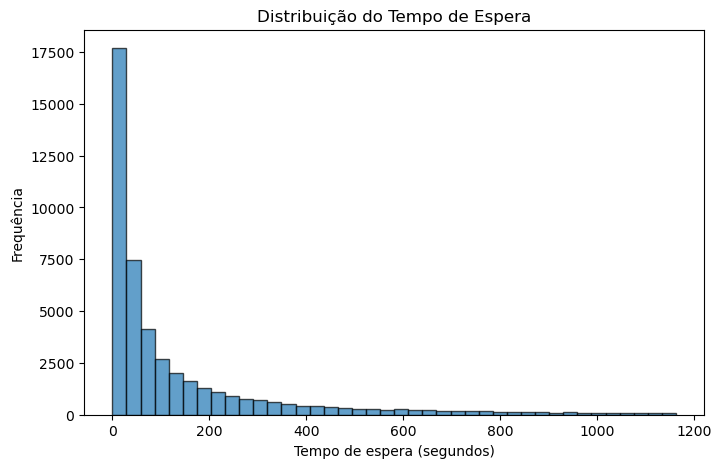

In [34]:
plt.figure(figsize=(8,5))

limit = data['waiting_time'].quantile(0.95)

plt.hist(data[data['waiting_time'] <= limit]['waiting_time'],
         bins=40,
         edgecolor='black',
         alpha=0.7)

plt.title('Distribuição do Tempo de Espera')
plt.xlabel('Tempo de espera (segundos)')
plt.ylabel('Frequência')

plt.show()


C:\Users\victo\AppData\Local\Temp\ipykernel_13856\548201877.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  abandon_rate = data.groupby('waiting_group')['is_missed_call'].mean()


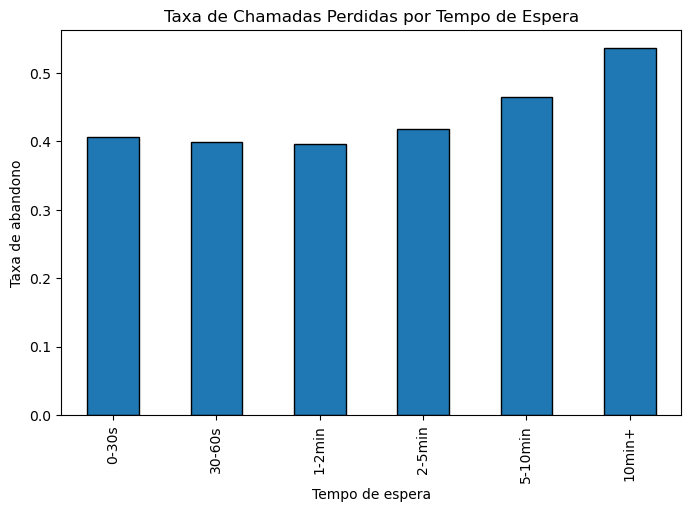

In [35]:
bins = [0, 30, 60, 120, 300, 600, data['waiting_time'].max()]
labels = ['0-30s', '30-60s', '1-2min', '2-5min', '5-10min', '10min+']

data['waiting_group'] = pd.cut(data['waiting_time'], bins=bins, labels=labels)

abandon_rate = data.groupby('waiting_group')['is_missed_call'].mean()

plt.figure(figsize=(8,5))

abandon_rate.plot(kind='bar', edgecolor='black')

plt.title('Taxa de Chamadas Perdidas por Tempo de Espera')
plt.xlabel('Tempo de espera')
plt.ylabel('Taxa de abandono')

plt.show()

In [36]:
data['missed_call_numeric'] = data['is_missed_call'].astype(int)

correlation = data['waiting_time'].corr(data['missed_call_numeric'])

print(correlation)

0.047929051333906944


C:\Users\victo\AppData\Local\Temp\ipykernel_13856\1483824034.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_in['waiting_group'] = pd.cut(data_in['waiting_time'], bins=bins, labels=labels)
C:\Users\victo\AppData\Local\Temp\ipykernel_13856\1483824034.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  abandon_rate = data_in.groupby('waiting_group')['is_missed_call'].mean()


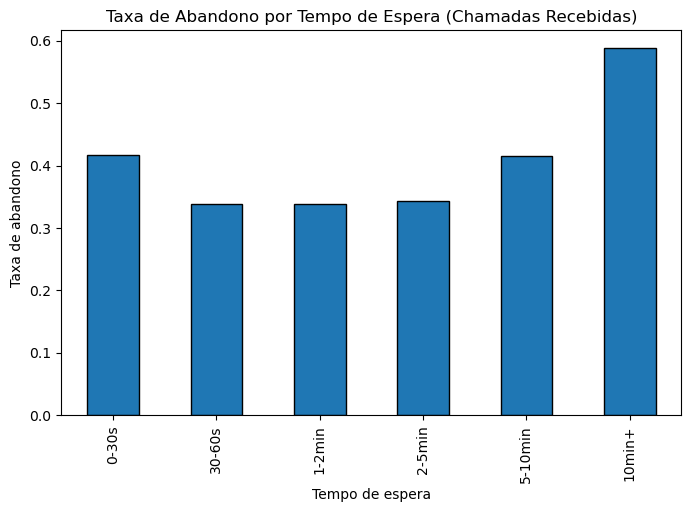

In [37]:
data_in = data[data['direction'] == 'in']

bins = [0, 30, 60, 120, 300, 600, data_in['waiting_time'].max()]
labels = ['0-30s', '30-60s', '1-2min', '2-5min', '5-10min', '10min+']

data_in['waiting_group'] = pd.cut(data_in['waiting_time'], bins=bins, labels=labels)

abandon_rate = data_in.groupby('waiting_group')['is_missed_call'].mean()

plt.figure(figsize=(8,5))

abandon_rate.plot(kind='bar', edgecolor='black')

plt.title('Taxa de Abandono por Tempo de Espera (Chamadas Recebidas)')
plt.xlabel('Tempo de espera')
plt.ylabel('Taxa de abandono')

plt.show()

In [38]:
data_in['missed_call_numeric'] = data_in['is_missed_call'].astype(int)

correlation = data_in['waiting_time'].corr(data_in['missed_call_numeric'])

print(correlation)

0.0560064657479467


C:\Users\victo\AppData\Local\Temp\ipykernel_13856\3039450727.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_in['missed_call_numeric'] = data_in['is_missed_call'].astype(int)


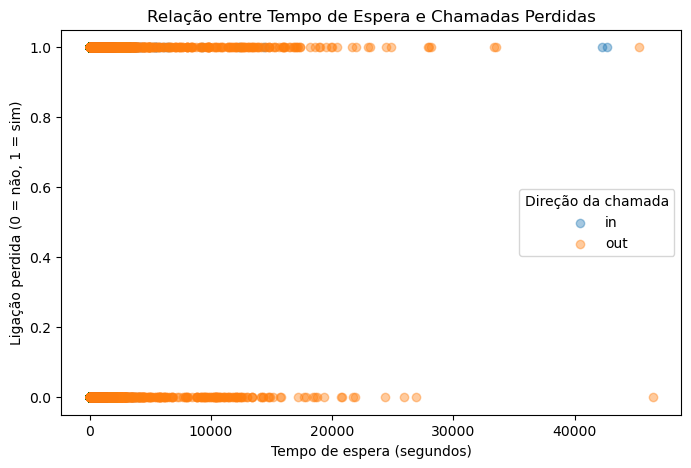

In [39]:
plt.figure(figsize=(8,5))

for direction in data['direction'].unique():
    subset = data[data['direction'] == direction]
    
    plt.scatter(
        subset['waiting_time'],
        subset['is_missed_call'],
        alpha=0.4,
        label=direction
    )

plt.xlabel('Tempo de espera (segundos)')
plt.ylabel('Ligação perdida (0 = não, 1 = sim)')
plt.title('Relação entre Tempo de Espera e Chamadas Perdidas')
plt.legend(title='Direção da chamada')

plt.show()

In [40]:
data_clients = data.merge(clients, on='user_id', how='left')

data_clients['tariff_plan'].value_counts()

tariff_plan
C    18209
B    17237
A    13556
Name: count, dtype: int64

In [41]:
data_clients.groupby('tariff_plan')['calls_count'].sum()

tariff_plan
A    439650
B    163573
C    203486
Name: calls_count, dtype: int64

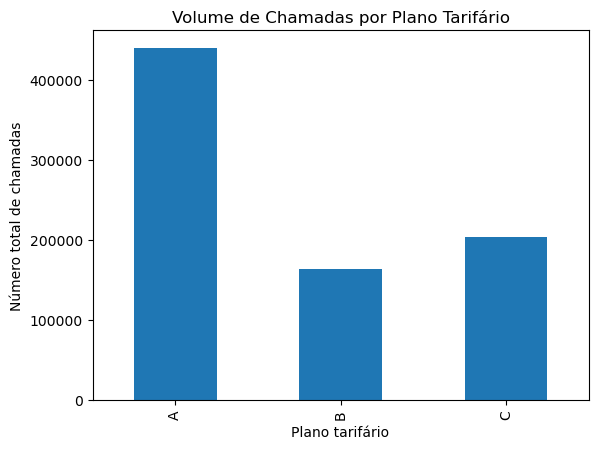

In [42]:
calls_by_plan = data_clients.groupby('tariff_plan')['calls_count'].sum()

calls_by_plan.plot(kind='bar')

plt.title('Volume de Chamadas por Plano Tarifário')
plt.xlabel('Plano tarifário')
plt.ylabel('Número total de chamadas')

plt.show()

In [43]:
data.groupby('operator_id')['calls_count'].sum().sort_values(ascending=False)

operator_id
885890.0    60221
885876.0    59429
929428.0    23754
925922.0    20021
908640.0    14239
            ...  
946020.0        1
946032.0        1
946468.0        1
947306.0        1
945274.0        1
Name: calls_count, Length: 1092, dtype: int64

In [44]:
operator_start = data.groupby('operator_id')['date'].min().sort_values()

operator_days = data.groupby('operator_id')['date'].nunique()

operator_days.describe()

count    1092.000000
mean       17.991758
std        18.771503
min         1.000000
25%         3.750000
50%        12.000000
75%        26.250000
max        97.000000
Name: date, dtype: float64

In [45]:
calls_per_operator = data.groupby('operator_id')['calls_count'].sum()

calls_per_day = calls_per_operator / operator_days

calls_per_day.sort_values(ascending=False).head()

operator_id
925922.0    834.208333
885890.0    752.762500
908640.0    749.421053
929428.0    719.818182
885876.0    612.670103
dtype: float64

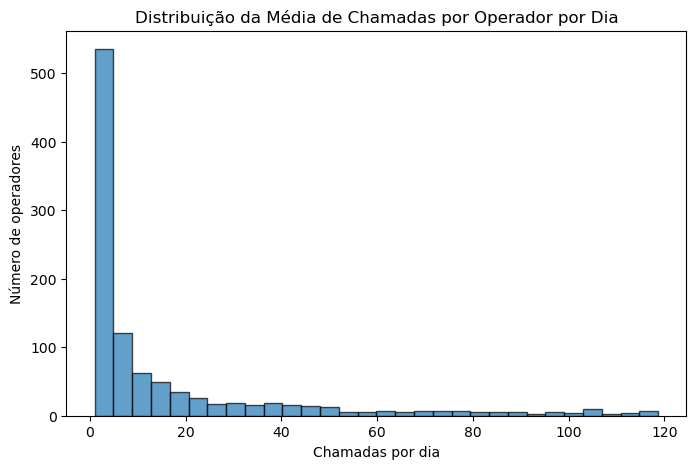

In [46]:
plt.figure(figsize=(8,5))

limit = calls_per_day.quantile(0.95)

plt.hist(calls_per_day[calls_per_day <= limit],
         bins=30,
         edgecolor='black',
         alpha=0.7)

plt.title('Distribuição da Média de Chamadas por Operador por Dia')
plt.xlabel('Chamadas por dia')
plt.ylabel('Número de operadores')

plt.show()

## Síntese da Análise Exploratória

A análise exploratória dos dados permitiu identificar alguns padrões gerais no comportamento das chamadas registradas na plataforma.

O dataset analisado contém 49.002 registros após a remoção de duplicatas, representando um volume total de aproximadamente 806 mil chamadas.
Observou-se que cada registro pode representar múltiplas chamadas, sendo o número de chamadas indicado pela variável `calls_count`. A distribuição dessa variável apresenta forte assimetria, com a maioria dos registros contendo poucas chamadas e alguns registros concentrando volumes muito elevados.

Em relação à direção das chamadas, a maior parte dos registros está associada a chamadas realizadas pelos operadores (`out`), em comparação com chamadas recebidas (`in`).

A análise das chamadas perdidas indicou que aproximadamente 46,6% das chamadas registradas não foram atendidas, representando uma parcela significativa do volume total de chamadas.
Apesar de notar um maior número de ligações perdidas com o aumento do tempo de espera, este aumento não explica diretamente o abandono das chamadas. Fraca correlação entre as variáveis.

A duração das chamadas apresentou alta dispersão, com grande diferença entre média e mediana, sugerindo a presença de valores extremos. Padrão semelhante foi observado no tempo de espera antes do atendimento.

Ao cruzar os dados de chamadas com as informações dos clientes, observou-se que os diferentes planos tarifários apresentam volumes distintos de chamadas. O plano A concentra o maior volume total de chamadas no dataset analisado.

Por fim, a análise da atividade dos operadores mostrou grande variação no número de chamadas associadas a cada operador, indicando uma distribuição heterogênea da carga de atendimento. A maioria dos operadores atende relativamente poucas chamadas por dia, enquanto um número menor de operadores concentra volumes mais elevados de atendimento.
A mediana observada foi de aproximadamente 12 chamadas por dia, enquanto a média foi de cerca de 18 chamadas por dia.
Esse padrão pode indicar diferenças na carga de trabalho entre operadores ou possíveis variações na participação dos operadores ao longo do período analisado.
No entanto, apenas essa métrica não é suficiente para concluir se a distribuição de chamadas entre operadores representa um gargalo operacional ou se existem outros fatores influenciando a taxa de chamadas perdidas.

Esses resultados fornecem uma visão inicial do comportamento das chamadas e servirão como base para a realização dos testes estatísticos nas próximas etapas da análise.

Observação: Devido a presença de outliers, os gráficos foram desenvolvidos limitando o eixo x ao percentil de 95% dos valores, a fim de melhorar a visualização dos dados.

## Teste de Hipóteses

Após a análise exploratória, serão realizados testes estatísticos com o objetivo de verificar se determinadas diferenças observadas nos dados podem ser consideradas estatisticamente significativas.

Os testes de hipóteses permitem avaliar se as diferenças entre grupos são resultado de variações aleatórias ou se indicam padrões reais no comportamento das chamadas.

Para todos os testes será utilizado um nível de significância de:

α = 0.05

Isso significa que a hipótese nula será rejeitada caso o valor-p seja inferior a 0.05.

---

### Hipótese 1 — Tempo de Espera e Chamadas Perdidas

Esta hipótese investiga se existe diferença no tempo de espera antes do início da conversa entre chamadas atendidas e chamadas perdidas.

Hipótese nula (H0):  
Não existe diferença significativa no tempo de espera entre chamadas atendidas e chamadas perdidas.

Hipótese alternativa (H1):  
Chamadas perdidas apresentam tempos de espera significativamente maiores do que chamadas atendidas.

Caso a hipótese alternativa seja confirmada, isso pode indicar que tempos maiores antes do início da conversa estão associados a uma maior probabilidade de chamadas não serem completadas.

---

### Hipótese 2 — Chamadas de Entrada vs Chamadas de Saída

Esta hipótese busca avaliar se a proporção de chamadas perdidas difere entre chamadas recebidas (in) e chamadas realizadas pelos operadores (out).

Hipótese nula (H0):  
A proporção de chamadas perdidas é semelhante entre chamadas de entrada e chamadas de saída.

Hipótese alternativa (H1):  
A proporção de chamadas perdidas é diferente entre chamadas de entrada e chamadas de saída.

Caso exista diferença significativa, isso pode indicar que o comportamento dos clientes ou o processo de contato influencia a probabilidade de uma chamada ser perdida.

---

### Hipótese 3 — Eficiência Operacional dos Operadores

Esta hipótese investiga se operadores com maior volume de chamadas atendidas apresentam menor proporção de chamadas perdidas.

Hipótese nula (H0):  
Não existe relação entre o volume de chamadas atendidas por operador e a proporção de chamadas perdidas.

Hipótese alternativa (H1):  
Operadores com maior volume de chamadas apresentam menor proporção de chamadas perdidas.

Caso essa hipótese seja confirmada, isso pode indicar que operadores mais ativos ou experientes tendem a apresentar melhor desempenho no atendimento de chamadas.

### Teste de Hipótese 1 — Volume de Chamadas por Plano Tarifário

In [48]:
alpha = 0.05

answered = data[data['is_missed_call'] == False]['waiting_time']
missed = data[data['is_missed_call'] == True]['waiting_time']

stat, p_value = stats.mannwhitneyu(answered, missed)

print("p-value:", p_value)

if p_value < alpha:
    print("Rejeitamos H0")
else:
    print("Não rejeitamos H0")

p-value: 0.021399971136571414
Rejeitamos H0


### Teste de Hipótese 2 — Chamadas de Entrada vs Chamadas de Saída

In [49]:
missed_in = data[data['direction'] == 'in']['is_missed_call']
missed_out = data[data['direction'] == 'out']['is_missed_call']

stat, p_value = stats.mannwhitneyu(missed_in, missed_out)

print("p-value:", p_value)

if p_value < alpha:
    print("Rejeitamos H0")
else:
    print("Não rejeitamos H0")

p-value: 1.7642488457279816e-58
Rejeitamos H0


### Teste de Hipótese 3 — Eficiência Operacional dos Operadores

In [50]:
operator_stats = data.groupby('operator_id').agg(
    total_calls=('calls_count','sum'),
    missed_calls=('is_missed_call','sum')
)

operator_stats['missed_rate'] = operator_stats['missed_calls'] / operator_stats['total_calls']

stat, p_value = stats.spearmanr(
    operator_stats['total_calls'],
    operator_stats['missed_rate']
)

print("correlation:", stat)
print("p-value:", p_value)

if p_value < alpha:
    print("Rejeitamos H0")
else:
    print("Não rejeitamos H0")

correlation: -0.1323994360411146
p-value: 1.1360011292521566e-05
Rejeitamos H0


## Resultados dos Testes de Hipóteses

Os testes estatísticos foram realizados utilizando nível de significância α = 0.05.

### Hipótese 1 — Tempo de Espera e Chamadas Perdidas

Para avaliar se existe diferença no tempo de espera entre chamadas atendidas e chamadas perdidas, foi utilizado o teste não paramétrico de Mann-Whitney, uma vez que a distribuição da variável `waiting_time` apresenta forte assimetria.

Resultado do teste:

p-value = 0.021

Como o valor-p é menor que o nível de significância estabelecido (0.05), a hipótese nula foi rejeitada.

Esse resultado indica que existe diferença estatisticamente significativa no tempo de espera entre chamadas atendidas e chamadas perdidas. Isso sugere que o tempo antes do início da conversa pode estar associado à probabilidade de uma chamada não ser completada.

---

### Hipótese 2 — Chamadas de Entrada vs Chamadas de Saída

Para avaliar se a proporção de chamadas perdidas difere entre chamadas recebidas pelos operadores (`in`) e chamadas realizadas pelos operadores (`out`), foi utilizado o teste não paramétrico de Mann-Whitney.

Resultado do teste:

p-value = 1.76 × 10⁻⁵⁸

Como o valor-p é significativamente menor que o nível de significância estabelecido, a hipótese nula foi rejeitada.

Esse resultado indica que existe diferença estatisticamente significativa na proporção de chamadas perdidas entre chamadas de entrada e chamadas de saída, sugerindo que o tipo de chamada pode influenciar a probabilidade de uma chamada não ser completada.

---

### Hipótese 3 — Eficiência Operacional dos Operadores

Para avaliar se existe relação entre o volume de chamadas associadas a cada operador e a proporção de chamadas perdidas, foi utilizado o teste de correlação de Spearman.

Resultado do teste:

correlation = -0.132  
p-value = 1.13 × 10⁻⁵

Como o valor-p é menor que o nível de significância estabelecido, a hipótese nula foi rejeitada.

O coeficiente de correlação negativo indica que operadores com maior volume de chamadas tendem a apresentar proporções ligeiramente menores de chamadas perdidas. Embora a magnitude da correlação seja fraca, o resultado sugere uma possível relação entre experiência ou atividade do operador e melhor desempenho no atendimento das chamadas.

## Conclusão Final

Este projeto teve como objetivo analisar os dados de chamadas da plataforma CallMeMaybe para identificar padrões de utilização do serviço e possíveis fatores que influenciam o desempenho das operações de atendimento.

A análise foi conduzida em três etapas principais: exploração inicial dos dados, limpeza e preparação das informações, e realização de testes estatísticos para avaliar hipóteses específicas.

A análise exploratória mostrou que o dataset contém aproximadamente 806 mil chamadas registradas, distribuídas em cerca de 49 mil registros agregados. Observou-se grande variação no número de chamadas por registro, bem como alta dispersão nas métricas de duração das chamadas e tempo de espera.

A taxa de chamadas perdidas identificada foi de aproximadamente 46,6%, indicando que uma parcela significativa das chamadas registradas não foi completada.

A análise também mostrou que muitos operadores possuem volumes relativamente baixos de chamadas por dia, enquanto uma parcela menor concentra grande parte da atividade de atendimento.

Outro ponto relevante observado durante a análise foi que o tempo de espera registrado nas chamadas pode representar, em muitos casos, o período em que o telefone do cliente está tocando antes de ser atendido, especialmente em chamadas realizadas pelos operadores. Isso sugere que parte das chamadas perdidas pode estar associada ao comportamento de resposta dos clientes, e não exclusivamente a problemas de eficiência operacional.

Os testes estatísticos realizados permitiram avaliar três hipóteses relacionadas ao comportamento das chamadas.

Os resultados indicaram que:

- existe diferença estatisticamente significativa no tempo de espera entre chamadas atendidas e chamadas perdidas;
- existe diferença significativa na proporção de chamadas perdidas entre chamadas de entrada e chamadas de saída;
- existe uma correlação negativa, ainda que fraca, entre o volume de chamadas por operador e a proporção de chamadas perdidas.

Esses resultados sugerem que fatores como o tempo antes da conexão da chamada, o tipo de chamada realizada e o nível de atividade dos operadores podem influenciar o resultado das chamadas registradas na plataforma.

De forma geral, a análise fornece uma visão inicial sobre padrões de funcionamento da operação de chamadas e pode servir como base para investigações mais detalhadas sobre eficiência operacional, comportamento dos clientes e possíveis estratégias para reduzir a taxa de chamadas perdidas.